Написать фильтры изображения:
- ЧБ фильтр изображения
- Занулить один из каналов RGB
- Изменить положение картинки (Отзеркалить, повернуть)

Требования для картинки:
- min разрешение 480p
- max разрешение 1080p

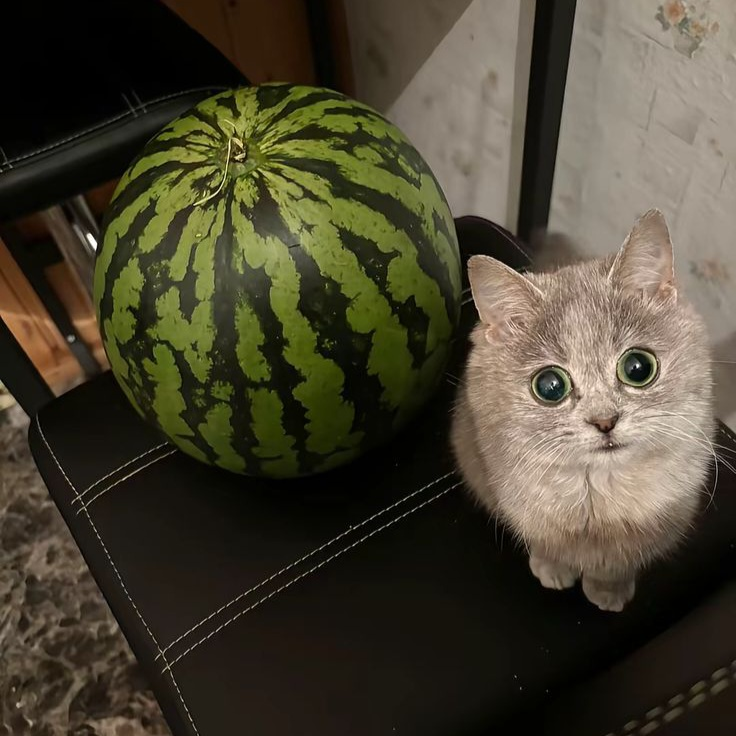

In [54]:
from PIL import Image, ImageDraw #Подключим необходимые библиотеки. 

 #Считываем номер преобразования. 
image = Image.open("./data/test_img_sq.jpg") #Открываем изображение. 
draw = ImageDraw.Draw(image) #Создаем инструмент для рисования. 
width = image.size[0] #Определяем ширину. 
height = image.size[1] #Определяем высоту. 	
pix = image.load() #Выгружаем значения пикселей.
image

In [55]:
def BW_filter(image, factor=100):
    bw_image = image.copy()
    draw = ImageDraw.Draw(bw_image) #Создаем инструмент для рисования.
    width = bw_image.size[0] #Определяем ширину. 
    height = bw_image.size[1] #Определяем высоту.
    pix = bw_image.load() #Выгружаем значения пикселей.
    
    for i in range(width):
        for j in range(height):
            a = pix[i, j][0]
            b = pix[i, j][1]
            c = pix[i, j][2]
            S = a + b + c
            if (S > factor * 3):
                a, b, c = 255, 255, 255
            else:
                a, b, c = 0, 0, 0
            draw.point((i, j), (a, b, c))
    del draw
    return bw_image

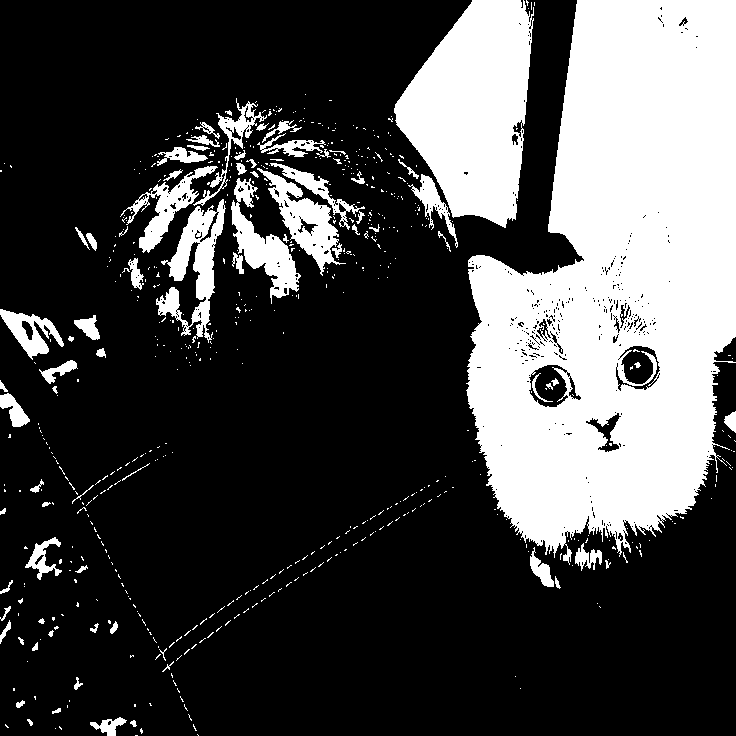

In [56]:
bw_image = BW_filter(image, 100)
bw_image

In [57]:
def Zanulator_filter(image, chanel):
    null_image = image.copy()
    draw = ImageDraw.Draw(null_image) #Создаем инструмент для рисования.
    width = null_image.size[0] #Определяем ширину. 
    height = null_image.size[1] #Определяем высоту.
    pix = null_image.load() #Выгружаем значения пикселей.
    
    for i in range(width):
        for j in range(height):
            rgb = [
                pix[i, j][0], 
                pix[i, j][1],
                pix[i, j][2]
                ]
            rgb[chanel] = 0
            
            draw.point((i, j), tuple(rgb))
    del draw
    return null_image

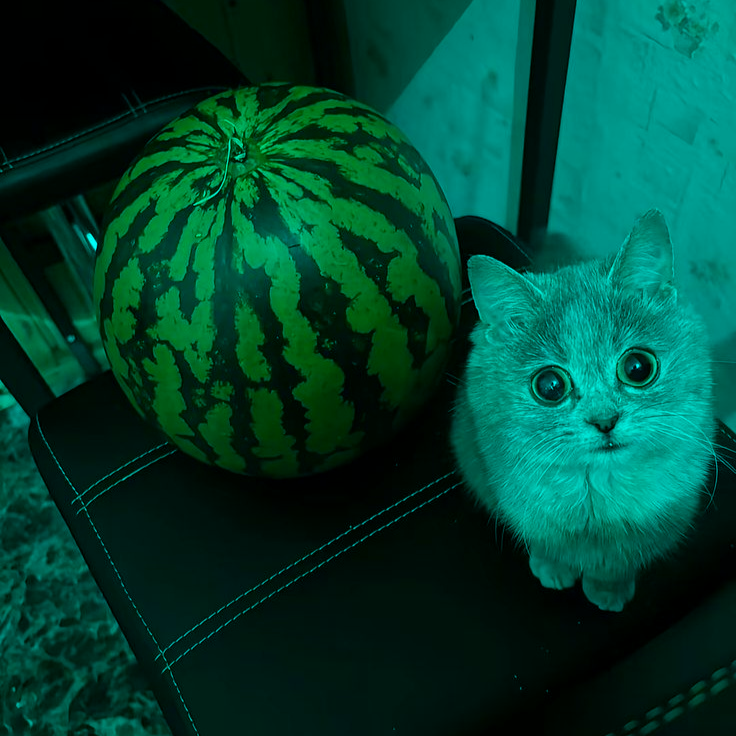

In [64]:
zero_image = Zanulator_filter(image, 0)
zero_image

In [84]:
def Rotate_image(image):
    width = image.size[0] #Определяем ширину. 
    height = image.size[1] #Определяем высоту.
    
    rot_image = image.copy()
    draw = ImageDraw.Draw(rot_image) #Создаем инструмент для рисования.
    
    pix = image.load() #Выгружаем значения пикселей.
    
    if width == height:
        for i in range(width):
            for j in range(height):
                pixel = pix[i, j]
                
                point = (height - i - 1, width - j - 1)
                
                
                
                draw.point(point, pixel)
                
    del draw
    return rot_image

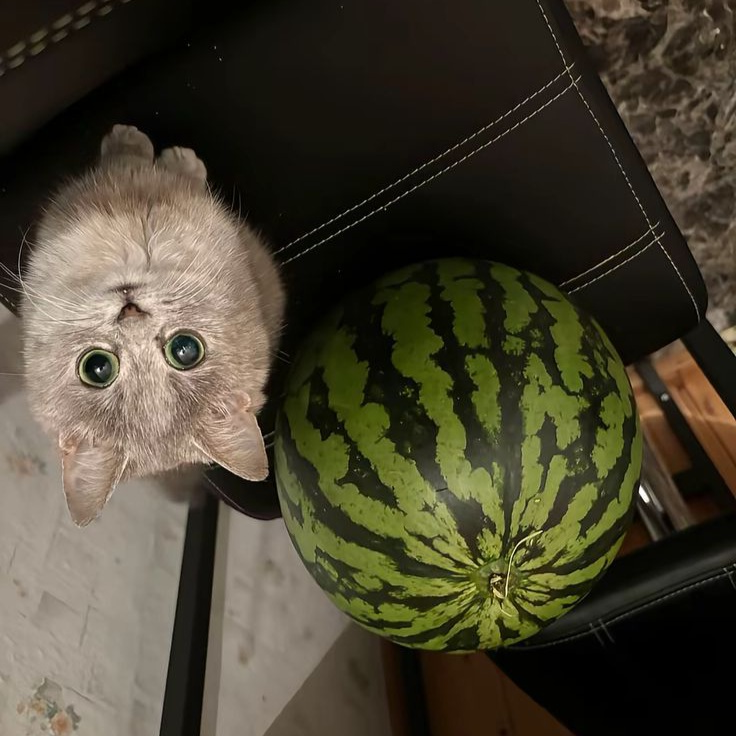

In [85]:
rot_image = Rotate_image(image)
rot_image

In [73]:
def Mirror_image(image):
    width = image.size[0] #Определяем ширину. 
    height = image.size[1] #Определяем высоту.
    
    rot_image = image.copy()
    draw = ImageDraw.Draw(rot_image) #Создаем инструмент для рисования.
    
    pix = image.load() #Выгружаем значения пикселей.
    
    for i in range(width):
        for j in range(height):
            pixel = pix[i, j]
            
            point = (width - i - 1, j)
            
            draw.point(point, pixel)
                
    del draw
    return rot_image

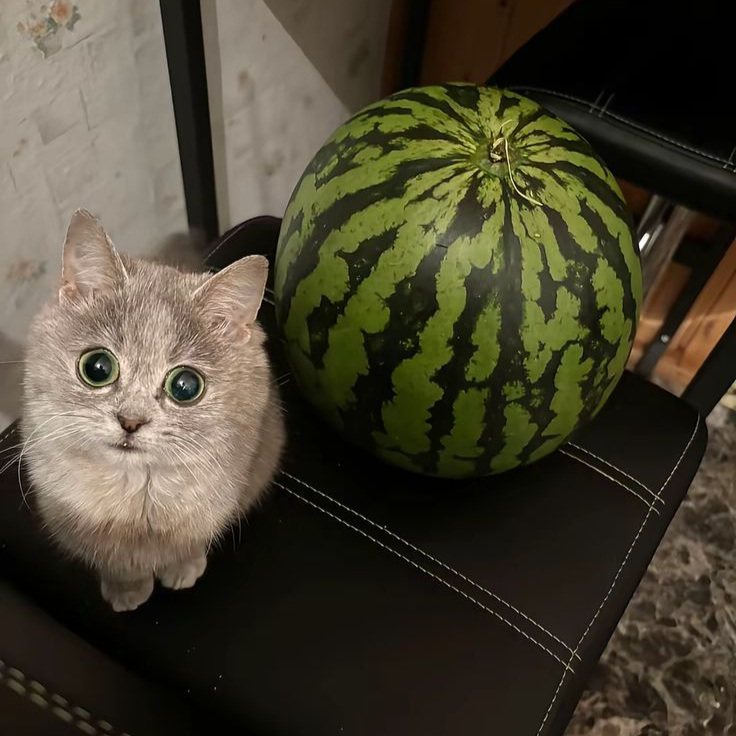

In [74]:
mr_image = Mirror_image(image)
mr_image